In [1]:
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn'], capture_output=True)
print("Installation done!")

Installation done!


In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 10000

df = pd.DataFrame({
    'age': np.random.randint(21, 65, n),
    'income': np.random.normal(50000, 20000, n).clip(10000),
    'loan_amount': np.random.normal(15000, 8000, n).clip(1000),
    'credit_score': np.random.normal(650, 100, n).clip(300, 850),
    'months_employed': np.random.randint(0, 300, n),
    'num_credit_lines': np.random.randint(1, 20, n),
    'interest_rate': np.random.uniform(5, 25, n),
    'loan_tenure': np.random.choice([12, 24, 36, 48, 60], n),
    'existing_loans': np.random.randint(0, 5, n),
})

# 90% safe, 10% default — imbalanced like real world
df['default'] = np.random.choice([0, 1], n, p=[0.90, 0.10])

df.to_csv('credit_risk.csv', index=False)
print(f"Dataset created: {df.shape}")
print(f"\nDefault distribution:")
print(df['default'].value_counts())

Dataset created: (10000, 10)

Default distribution:
default
0    9027
1     973
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('credit_risk.csv')

# Separate inputs (X) and output (y)
X = df.drop('default', axis=1)
y = df['default']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the numbers (make all columns same range)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"\nDefaults in training: {y_train.sum()}")
print(f"Defaults in testing:  {y_test.sum()}")


Training set: (8000, 9)
Testing set:  (2000, 9)

Defaults in training: 778
Defaults in testing:  195


In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_balanced).value_counts().to_dict()}")

Before SMOTE: {0: 7222, 1: 778}
After SMOTE:  {0: 7222, 1: 7222}


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(penalty='elasticnet', solver='saga',
                           l1_ratio=0.5, C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Safe', 'Default']))

              precision    recall  f1-score   support

        Safe       0.90      0.53      0.67      1805
     Default       0.10      0.46      0.16       195

    accuracy                           0.52      2000
   macro avg       0.50      0.50      0.41      2000
weighted avg       0.82      0.52      0.62      2000



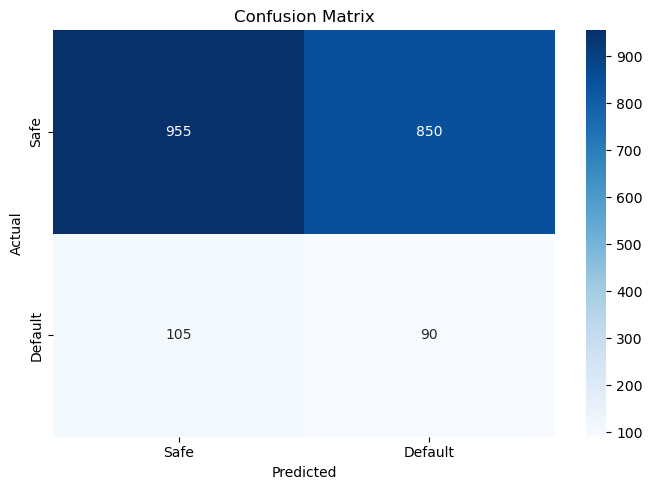

True Negatives (Correct Safe):    955
False Positives (Wrong Rejection): 850
False Negatives (Missed Default):  105
True Positives (Caught Default):   90


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Default'],
            yticklabels=['Safe', 'Default'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(f"True Negatives (Correct Safe):    {cm[0][0]}")
print(f"False Positives (Wrong Rejection): {cm[0][1]}")
print(f"False Negatives (Missed Default):  {cm[1][0]}")
print(f"True Positives (Caught Default):   {cm[1][1]}")

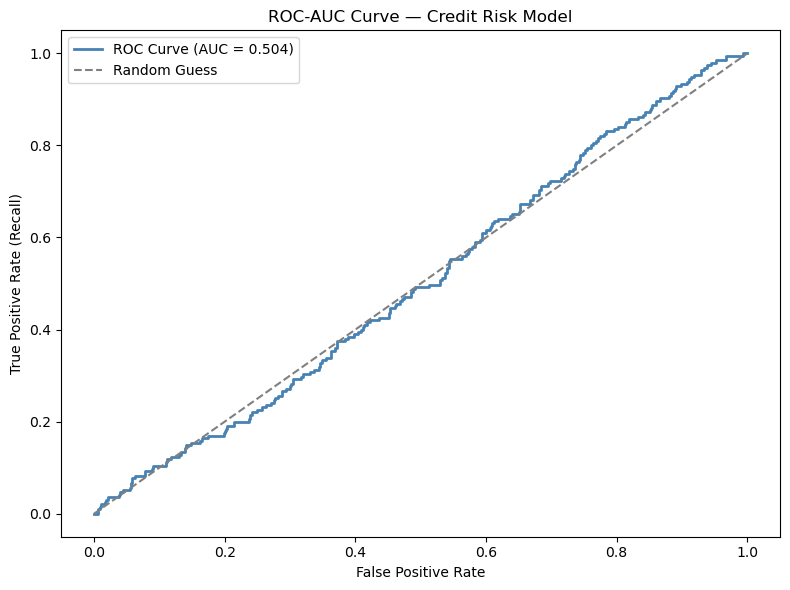

AUC Score: 0.504


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-AUC Curve — Credit Risk Model')
plt.legend()
plt.tight_layout()
plt.savefig('roc_auc_curve.png', dpi=150)
plt.show()
print(f"AUC Score: {auc_score:.3f}")

In [8]:
# Find threshold that balances precision and recall best
best_threshold = 0.5
best_score = 0

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    # Bank profit formula: catching defaults saves money, wrong rejections lose customers
    score = tp - (fp * 0.5)
    if score > best_score:
        best_score = score
        best_threshold = thresh

print(f"Best threshold for maximum bank profit: {best_threshold:.3f}")
y_final = (y_prob >= best_threshold).astype(int)
print("\nFinal Model Performance:")
print(classification_report(y_test, y_final, target_names=['Safe', 'Default']))

Best threshold for maximum bank profit: 0.500

Final Model Performance:
              precision    recall  f1-score   support

        Safe       0.90      0.53      0.67      1805
     Default       0.10      0.46      0.16       195

    accuracy                           0.52      2000
   macro avg       0.50      0.50      0.41      2000
weighted avg       0.82      0.52      0.62      2000

